Information: Jupyter Notebook for model performance evaluation.
Importance: Runs inference on testing set, outputs classification tables, calculates ROC-AUC, and plots Confusion Matrices and ROC curves.


# Model Performance Evaluation

This notebook loads the trained **best_model.h5** and evaluates it on the testing set. It computes:
- Categorical Accuracy, Precision, Recall, and F1-Scores.
- Multi-class One-vs-Rest ROC-AUC.
- Plots the Confusion Matrix.
- Plots the ROC curves for each class.

In [2]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

# Add root directory to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from training.data_loader import get_data_loaders

### 1. Load the Model and Test Dataset

In [3]:
model_path = os.path.abspath(os.path.join(os.getcwd(), "..", "models", "best_model.h5"))
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Trained model not found at {model_path}. Please train the model first!")

print(f"[Evaluation] Loading model from {model_path}...")
model = tf.keras.models.load_model(model_path, compile=False)

train_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "Brain Tumor data", "Training"))
test_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "Brain Tumor data", "Testing"))

_, test_ds = get_data_loaders(
    train_dir=train_dir,
    test_dir=test_dir,
    image_size=224,
    batch_size=32
)

[Evaluation] Loading model from C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5...
Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


### 2. Run Inference on testing set

In [4]:
print("[Evaluation] Running inference...")
all_probs = model.predict(test_ds, verbose=1)
all_preds = np.argmax(all_probs, axis=1)

# Extract true labels
true_labels_list = []
for _, labels in test_ds:
    true_labels_list.append(labels.numpy())

all_labels_onehot = np.concatenate(true_labels_list, axis=0)
all_labels_indices = np.argmax(all_labels_onehot, axis=1)

class_names = ["glioma", "meningioma", "notumor", "pituitary"]

[Evaluation] Running inference...
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 847ms/step


### 3. Print Classification Metrics and ROC-AUC

In [5]:
report_txt = classification_report(
    all_labels_indices,
    all_preds,
    target_names=class_names
)
print("=== Classification Report ===")
print(report_txt)

roc_auc_ovr = roc_auc_score(
    all_labels_onehot,
    all_probs,
    multi_class="ovr",
    average="macro"
)
print(f"ROC-AUC (One-vs-Rest, Macro-averaged): {roc_auc_ovr:.4f}")

# Save JSON report
eval_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "artifacts", "evaluation"))
os.makedirs(eval_dir, exist_ok=True)

report_dict = classification_report(all_labels_indices, all_preds, target_names=class_names, output_dict=True)
report_dict["roc_auc_macro_ovr"] = float(roc_auc_ovr)

with open(os.path.join(eval_dir, "metrics_report.json"), "w") as f:
    json.dump(report_dict, f, indent=4)

=== Classification Report ===
              precision    recall  f1-score   support

      glioma       0.95      0.97      0.96       300
  meningioma       0.98      0.85      0.91       306
     notumor       1.00      0.99      0.99       405
   pituitary       0.89      1.00      0.94       300

    accuracy                           0.96      1311
   macro avg       0.96      0.95      0.95      1311
weighted avg       0.96      0.96      0.96      1311

ROC-AUC (One-vs-Rest, Macro-averaged): 0.9976


### 4. Plot and Save Confusion Matrix

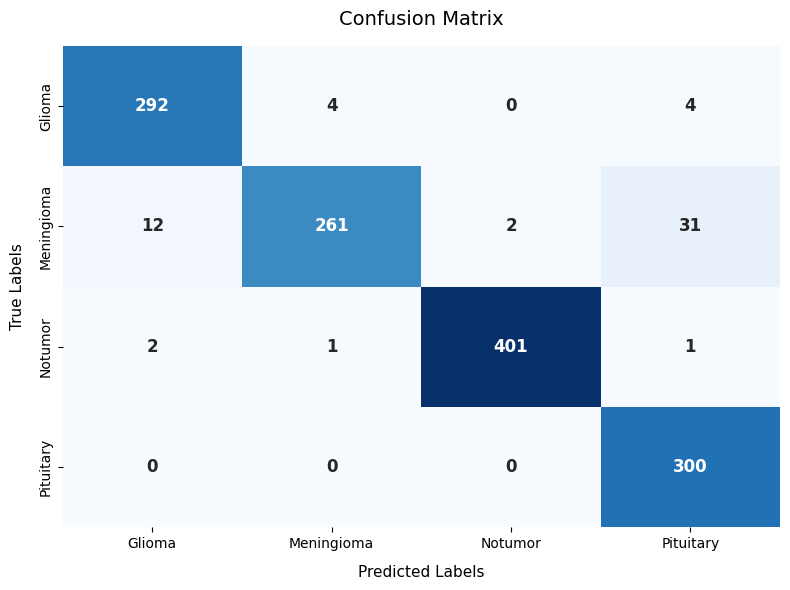

In [6]:
cm = confusion_matrix(all_labels_indices, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[c.capitalize() for c in class_names],
    yticklabels=[c.capitalize() for c in class_names],
    cbar=False,
    annot_kws={"size": 12, "weight": "bold"}
)
plt.title("Confusion Matrix", fontsize=14, pad=15)
plt.xlabel("Predicted Labels", fontsize=11, labelpad=10)
plt.ylabel("True Labels", fontsize=11, labelpad=10)
plt.tight_layout()

cm_path = os.path.join(eval_dir, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

### 5. Plot and Save ROC Curves

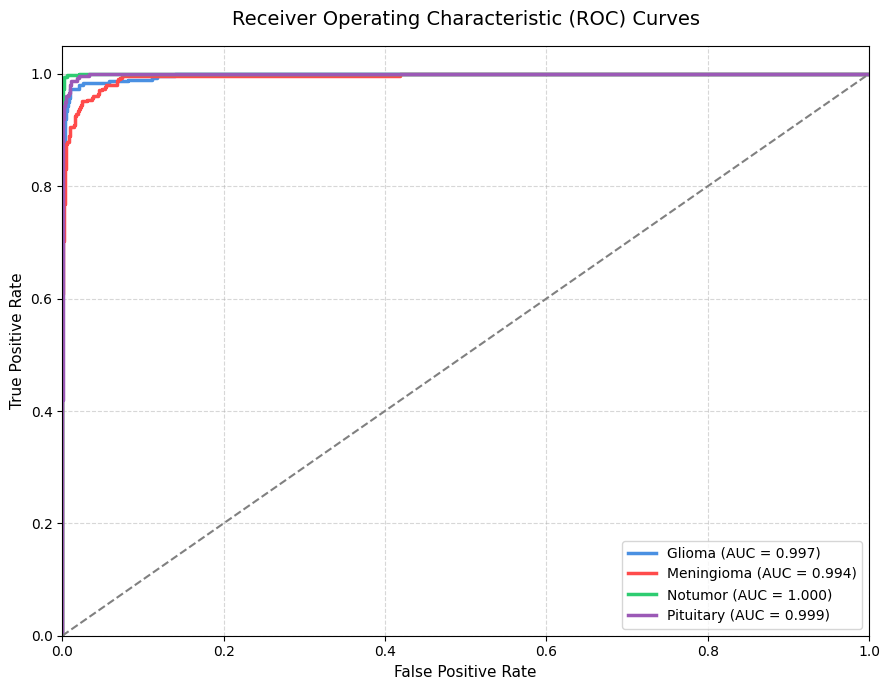

In [7]:
plt.figure(figsize=(9, 7))
colors = ["#4A90E2", "#FF4B4B", "#2ECC71", "#9B59B6"]

for idx, (class_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(all_labels_onehot[:, idx], all_probs[:, idx])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        color=color,
        lw=2.5,
        label=f"{class_name.capitalize()} (AUC = {roc_auc_val:.3f})"
    )

plt.plot([0, 1], [0, 1], color="grey", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("Receiver Operating Characteristic (ROC) Curves", fontsize=14, pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()

roc_path = os.path.join(eval_dir, "roc_curve.png")
plt.savefig(roc_path, dpi=300)
plt.show()